## SECTION 1: Setup & Imports
Week 1: Getting Started with Qiskit - Assignment Notebook

In [1]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import numpy as np

## SECTION 2: Single-Qubit Gates

### X Gate (NOT Gate)
Truth table:
- Input 0 $\rightarrow$ Output 1
- Input 1 $\rightarrow$ Output 0

Matrix:
$$
X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}
$$

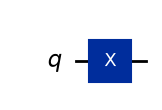

In [2]:
qc_x = QuantumCircuit(1)
qc_x.x(0)
qc_x.draw('mpl')

### Hadamard (H) Gate
Truth table:
- Input $|0\rangle$ $\rightarrow$ Output $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$
- Input $|1\rangle$ $\rightarrow$ Output $\frac{|0\rangle - |1\rangle}{\sqrt{2}}$

Matrix:
$$
H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}
$$

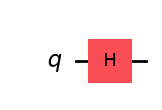

In [3]:
qc_h = QuantumCircuit(1)
qc_h.h(0)
qc_h.draw('mpl')

### Z Gate (Phase-flip Gate)
Truth table:
- Input $|0\rangle$ $\rightarrow$ Output $|0\rangle$
- Input $|1\rangle$ $\rightarrow$ Output $-|1\rangle$

Matrix:
$$
Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}
$$

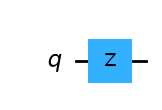

In [4]:
qc_z = QuantumCircuit(1)
qc_z.z(0)
qc_z.draw('mpl')

### T Gate
Truth table:
- Input $|0\rangle$ $\rightarrow$ Output $|0\rangle$
- Input $|1\rangle$ $\rightarrow$ Output $e^{i\pi/4}|1\rangle$

Matrix:
$$
T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}
$$

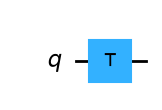

In [5]:
qc_t = QuantumCircuit(1)
qc_t.t(0)
qc_t.draw('mpl')

## SECTION 3: Multi-Qubit Gates

### CNOT (Controlled-NOT) Gate
Truth table:
- Input 00 $\rightarrow$ Output 00
- Input 01 $\rightarrow$ Output 01
- Input 10 $\rightarrow$ Output 11
- Input 11 $\rightarrow$ Output 10

Matrix:
$$
\text{CNOT} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}
$$

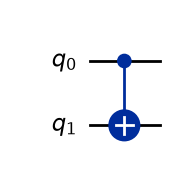

In [6]:
qc_cx = QuantumCircuit(2)
qc_cx.cx(0, 1)
qc_cx.draw('mpl')

### SWAP Gate
Truth table:
- Input 00 $\rightarrow$ Output 00
- Input 01 $\rightarrow$ Output 10
- Input 10 $\rightarrow$ Output 01
- Input 11 $\rightarrow$ Output 11

Matrix:
$$
\text{SWAP} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}
$$

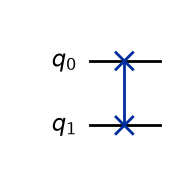

In [7]:
qc_swap = QuantumCircuit(2)
qc_swap.swap(0, 1)
qc_swap.draw('mpl')

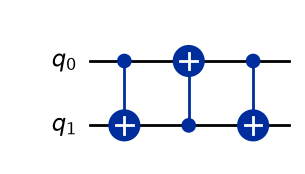

In [8]:
# Decompose SWAP into 3 CNOTs
qc_swap.decompose().draw('mpl')

### Toffoli (CCNOT) Gate
Truth table:
Inverts the target qubit if and only if both control qubits are 1.

Matrix:
$$
\text{Toffoli} = \begin{pmatrix} 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \end{pmatrix}
$$

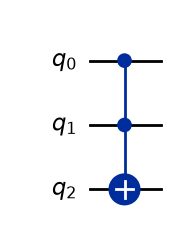

In [9]:
qc_ccx = QuantumCircuit(3)
qc_ccx.ccx(0, 1, 2)
qc_ccx.draw('mpl')

## SECTION 4: Measurements
Quantum measurement works by collapsing a superposition state probabilistically.

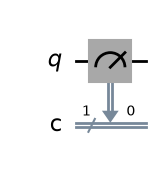

In [10]:
qc = QuantumCircuit(1, 1)
qc.measure(0, 0)
qc.draw('mpl')

## SECTION 5: Quantum Half-Adder Circuit (Main Exercise)
Using Qiskit patterns to implement a quantum half-adder.

### Step 1: Mapping

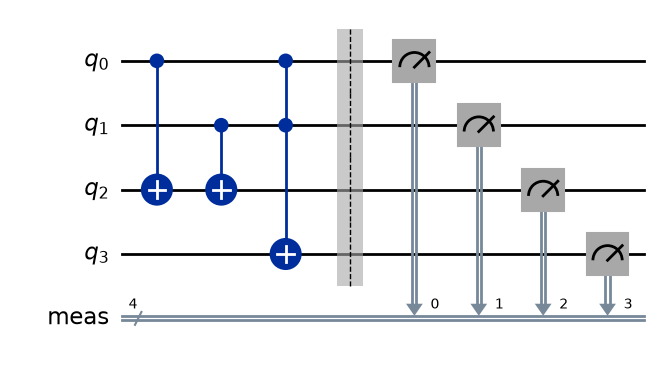

In [11]:
# Quantum Half-Adder Circuit
# qubits: A (q0), B (q1), Sum (q2), Carry (q3)
qc = QuantumCircuit(4)

# Choose values for A and B
a = 0
b = 0

# Prepare A and B qubits
if a:
    qc.x(0)
if b:
    qc.x(1)

# XOR (sum) into qubit 2
qc.cx(0, 2)
qc.cx(1, 2)

# AND (carry) into qubit 3
qc.ccx(0, 1, 3)

# Measure all qubits
qc.measure_all()

qc.draw('mpl')

### Step 2: Optimizing

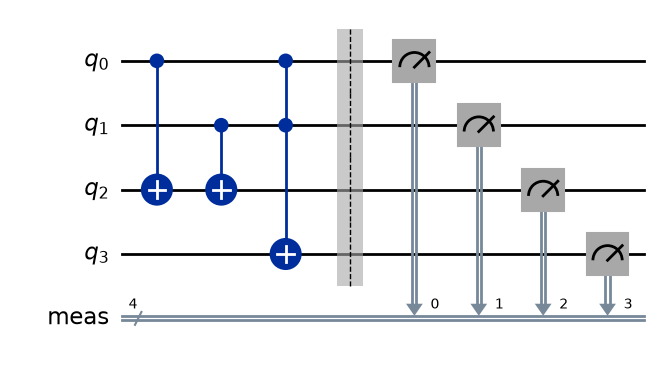

In [12]:
backend = AerSimulator()
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
qc_isa.draw('mpl')

### Step 3: Executing

In [13]:
sampler = BackendSamplerV2(backend=backend)
job = sampler.run([qc_isa], shots=1000)
res = job.result()
counts = res[0].data.meas.get_counts()

### Step 4: Post-processing

Counts: {'0000': 1000}


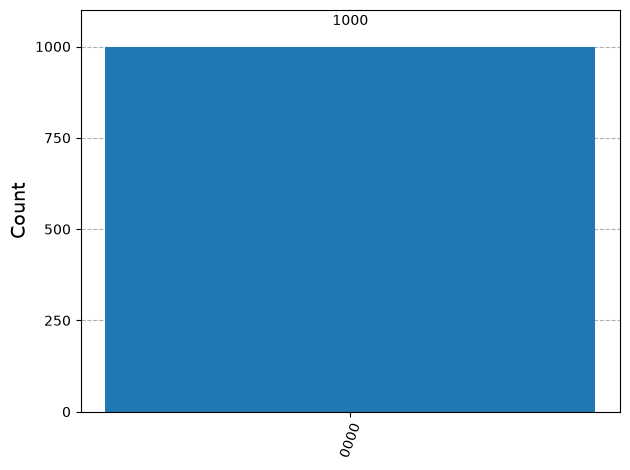

In [14]:
print("Counts:", counts)
plot_histogram(counts)

Verify A+B = S + 2*C for A=0, B=0 $\rightarrow$ 0+0 = 0+0 = 0 ✓

### Repeat for A=1, B=1

Counts: {'1011': 1000}


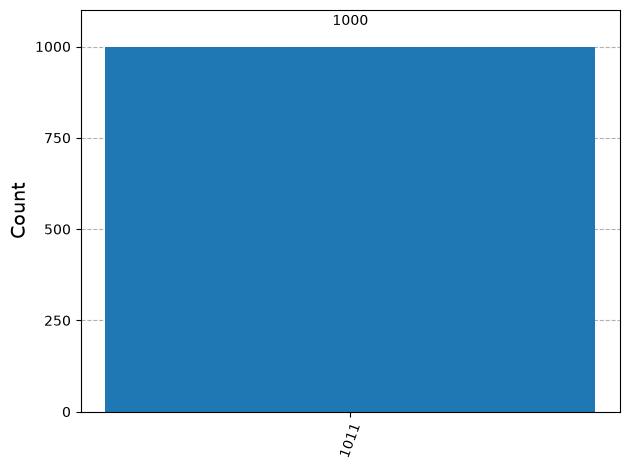

In [15]:
qc2 = QuantumCircuit(4)
a2, b2 = 1, 1
if a2: qc2.x(0)
if b2: qc2.x(1)
qc2.cx(0, 2)
qc2.cx(1, 2)
qc2.ccx(0, 1, 3)
qc2.measure_all()
qc2_isa = pm.run(qc2)
job2 = sampler.run([qc2_isa], shots=1000)
res2 = job2.result()
counts2 = res2[0].data.meas.get_counts()
print("Counts:", counts2)
plot_histogram(counts2)

Verify 1+1 = 0 + 2*1 = 2 ✓

## SECTION 6: Check Your Understanding Answers

1. **Binary representation of 86**: Need 7 bits. 86 = 64+16+4+2 = 1010110
2. **Verify half-adder truth table**: Show A+B = S + 2C for all 4 cases
3. **Little-endian notation**: Qubit 0 (rightmost) maps to $2^0$, qubit N-1 (leftmost) maps to $2^{N-1}$
4. **Two-qubit basis states in vector notation**: $|00\rangle$, $|01\rangle$, $|10\rangle$, $|11\rangle$ as 4D vectors
5. **Is $|11\rangle$ entangled?**: No, it's a product state $|1\rangle\otimes|1\rangle$
6. **CNOT matrix multiplication verification**: CNOT$|01\rangle$ = $|11\rangle$

In [16]:
cnot = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])
state_01 = np.array([0,1,0,0])
print(np.dot(cnot, state_01))

[0 1 0 0]


7. **SWAP = 3 CNOTs verification**:

In [17]:
cnot_10 = np.array([[1,0,0,0],[0,0,0,1],[0,0,1,0],[0,1,0,0]])
print(np.dot(cnot, np.dot(cnot_10, cnot)))

[[1 0 0 0]
 [0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]]


8. **Which gate replaces AND?**: Toffoli gate
9. **Verify quantum adder results**: Already done in section 5

## SECTION 7: True/False Questions
1. True
2. False (entanglement means states ARE correlated/dependent)
3. False (quantum gates are reversible/unitary)
4. False (q0 is rightmost, not leftmost)
5. False (measurement is probabilistic for superposition states)
6. True
7. True
8. False (it's $2^N$, not 2N)
9. True

## SECTION 8: Short Answer Questions
1. Bits vs Qubits differences
2. Measurement collapses superposition
3. Little-endian maps qubit index to power of 2
4. Map, Optimize, Execute, Post-process

## SECTION 9: Challenge Question 1 - Superposition Inputs to Half-Adder
Explain we're putting A and B in superposition using Hadamard gates

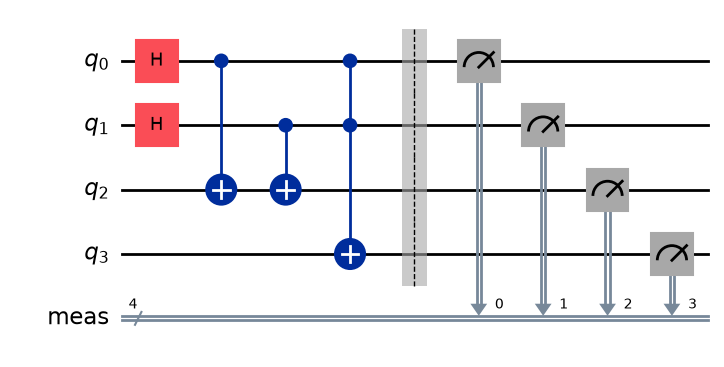

In [18]:
# Challenge 1: Half-Adder with superposition inputs
qc_super = QuantumCircuit(4)

# Put A and B in equal superposition
qc_super.h(0)  # Hadamard on A
qc_super.h(1)  # Hadamard on B

# XOR (sum)
qc_super.cx(0, 2)
qc_super.cx(1, 2)

# AND (carry)
qc_super.ccx(0, 1, 3)

qc_super.measure_all()
qc_super.draw('mpl')

In [19]:
qc_super_isa = pm.run(qc_super)
job_super = sampler.run([qc_super_isa], shots=1000)
res_super = job_super.result()
counts_super = res_super[0].data.meas.get_counts()

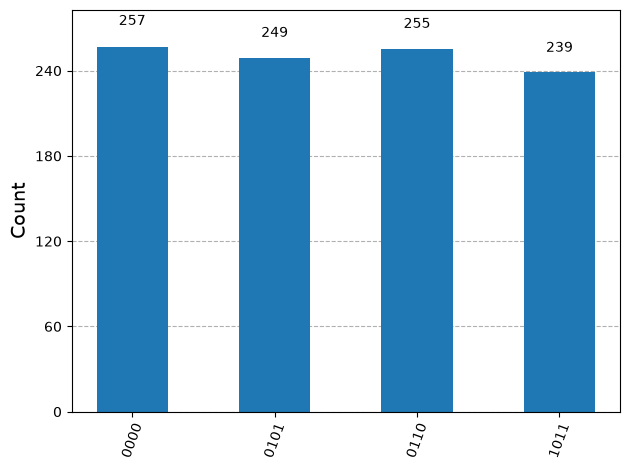

In [20]:
plot_histogram(counts_super)

Explain the results - we should see approximately equal counts of 0000 (0+0=0), 0101 (0+1=1), 0110 (1+0=1), and 1011 (1+1=2), showing the adder correctly computes all four sums simultaneously via superposition!

## SECTION 10: Challenge Question 2 - Toffoli Gate Decomposition
Explain we're decomposing the Toffoli into single and two-qubit gates

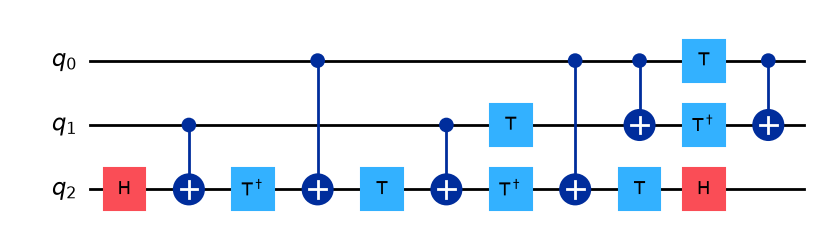

In [21]:
# Challenge 2: Toffoli gate decomposition
qc_toff = QuantumCircuit(3)
qc_toff.ccx(0, 1, 2)
qc_toff_decomposed = qc_toff.decompose()
qc_toff_decomposed.draw('mpl')

In [22]:
from qiskit.quantum_info import Operator

# Get unitary of original Toffoli
qc_original = QuantumCircuit(3)
qc_original.ccx(0, 1, 2)
op_original = Operator(qc_original)

# Get unitary of decomposed circuit
op_decomposed = Operator(qc_toff_decomposed)

# Check they are equivalent
print("Are they equivalent?", op_original.equiv(op_decomposed))
print("\nOriginal Toffoli matrix:")
print(np.round(op_original.data.real, 3))
print("\nDecomposed circuit matrix:")
print(np.round(op_decomposed.data.real, 3))

Are they equivalent? True

Original Toffoli matrix:
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]

Decomposed circuit matrix:
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]
